<a href="https://colab.research.google.com/github/2403a54127-lab/-PRODIGY_WD_05-/blob/main/Prodigy_WD_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (258266, 14)
  Accident_ID  Severity Weather_Condition Road_Condition  Temperature_F  \
0    A0000000         1               Fog            Dry              0   
1    A0000001         4            Cloudy            Icy             43   
2    A0000002         3            Cloudy            Wet             10   
3    A0000003         2               Fog            Icy              9   
4    A0000004         2              Snow            Dry             11   

   Visibility_mi State      City  Hour   Latitude   Longitude  \
0           5.67    NC   Houston   9.0  42.616696  -94.131212   
1           2.21    VA   Houston   6.0  37.530960 -109.378235   
2           9.73    VA   Houston  17.0  44.001251 -105.845227   
3           7.27    CA  New York  11.0  43.447805  -87.927807   
4           2.26    FL     Miami   5.0  47.545082  -75.131766   

   Vehicles_Involved  Casualties Sunrise_Sunset  
0                3.0         4.0            Day  
1                3.0         3

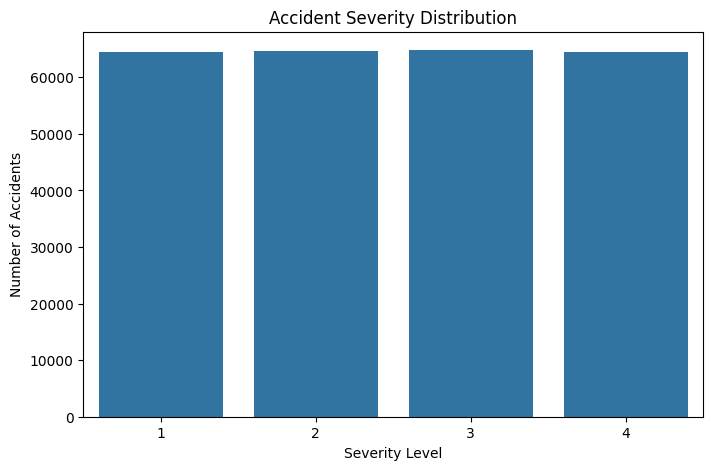

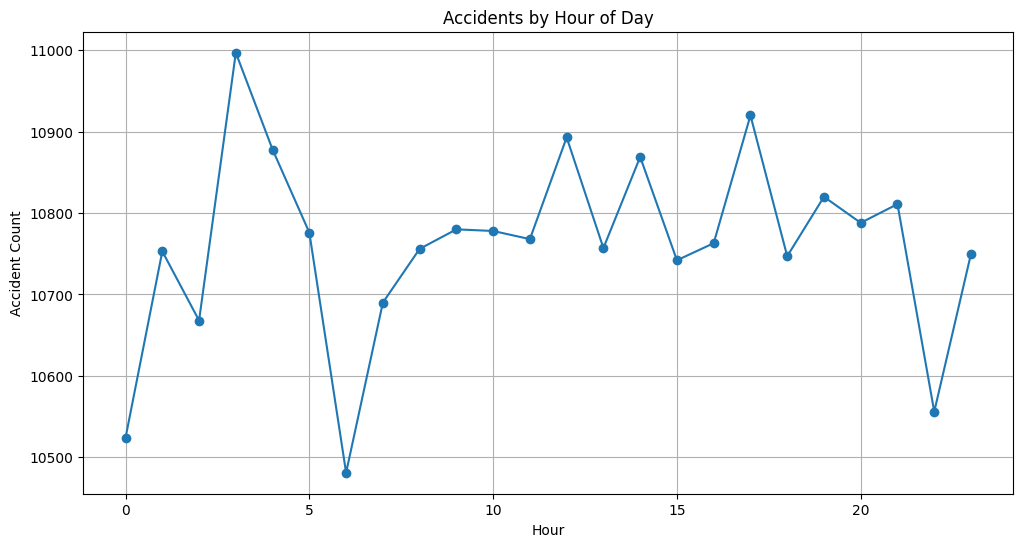

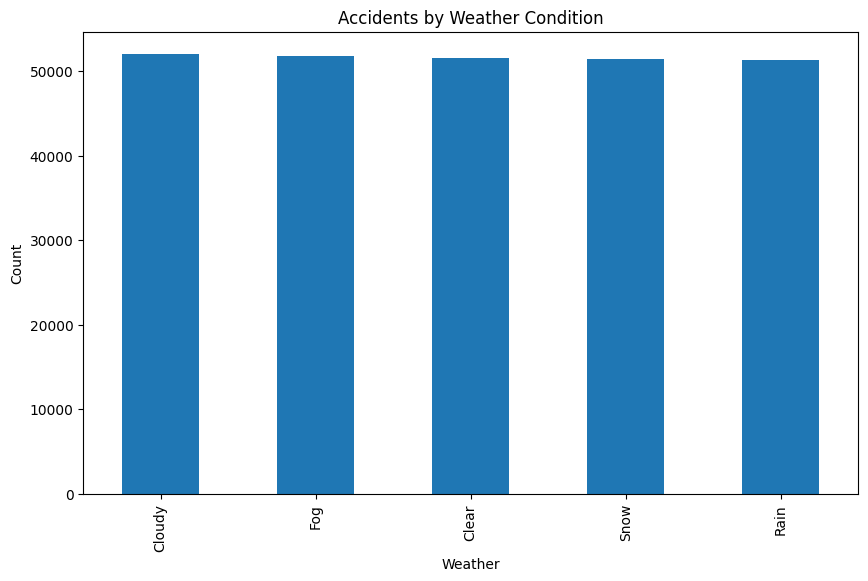

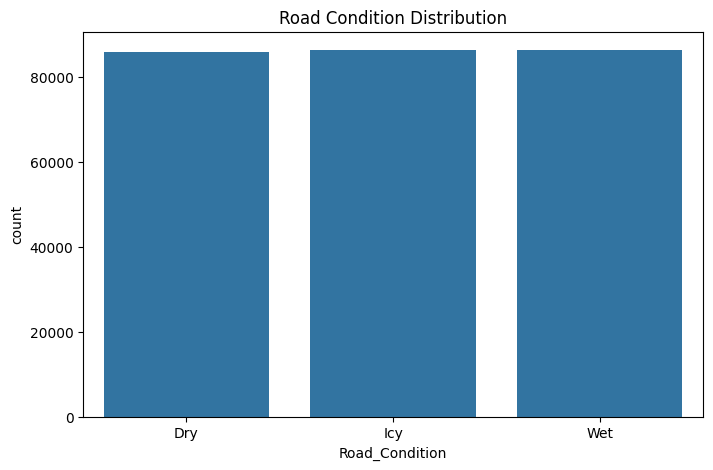

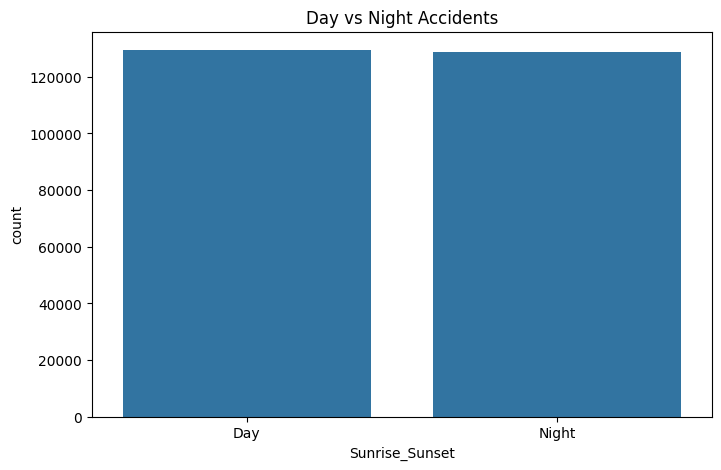

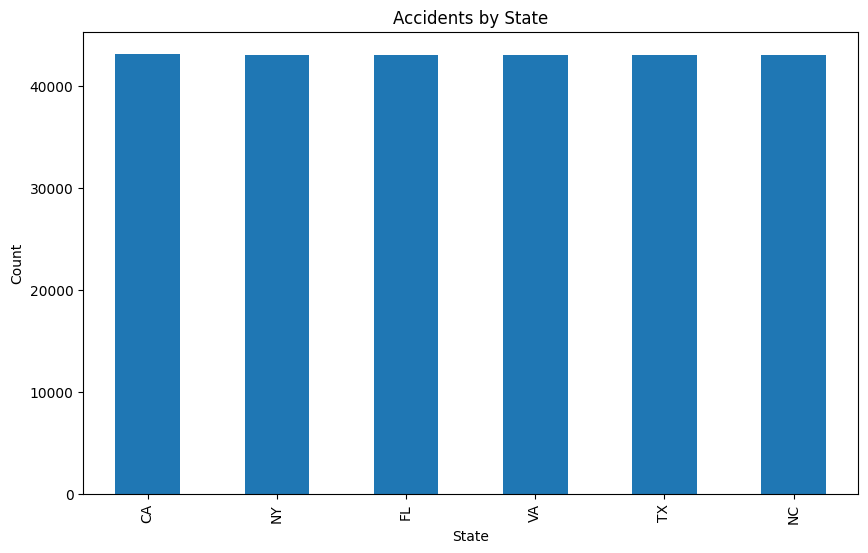

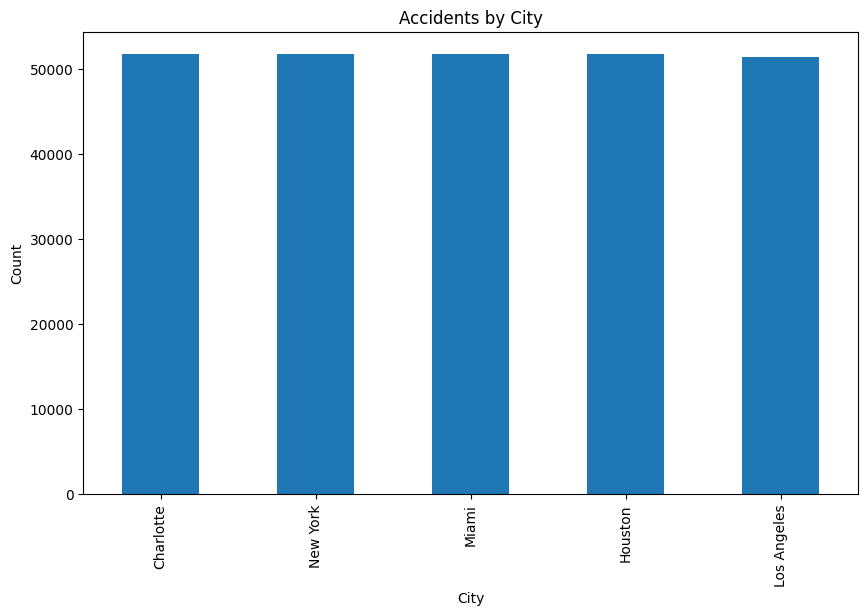

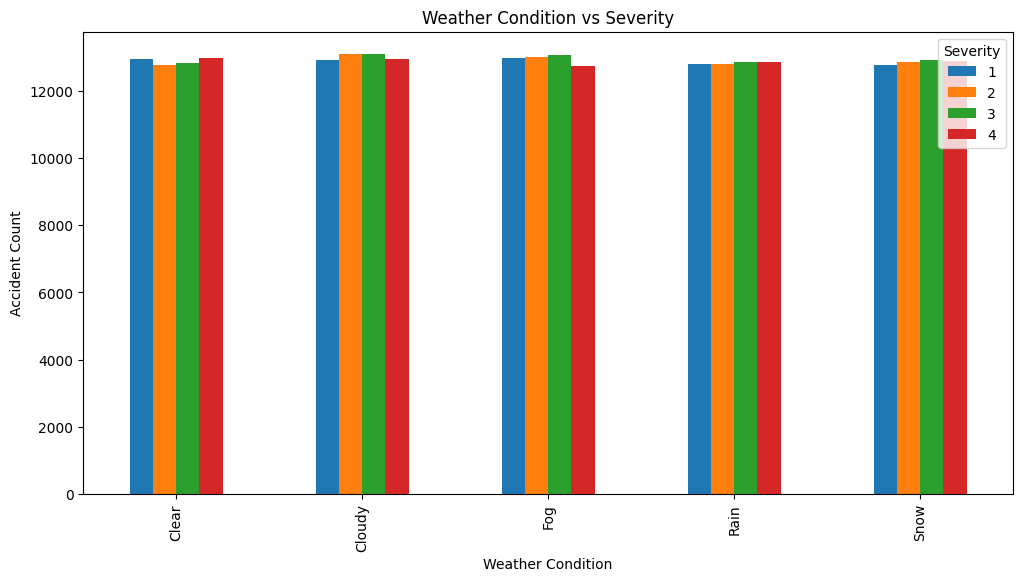

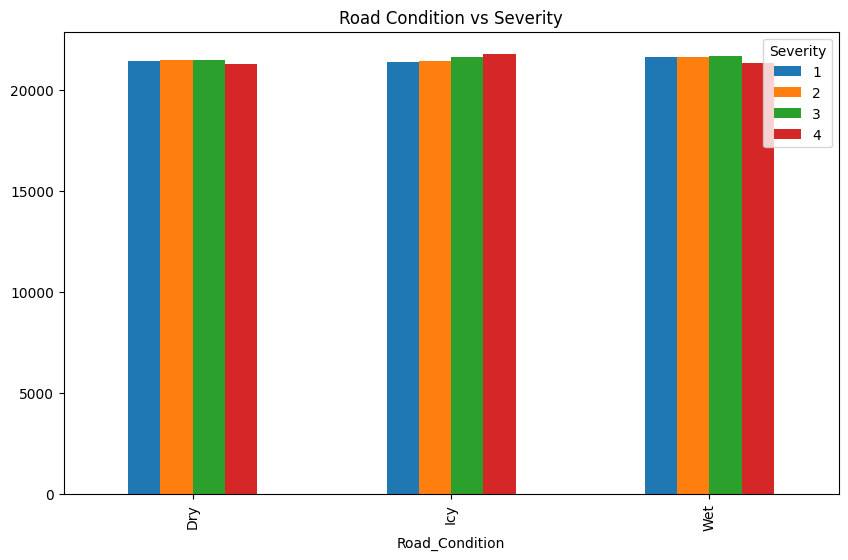

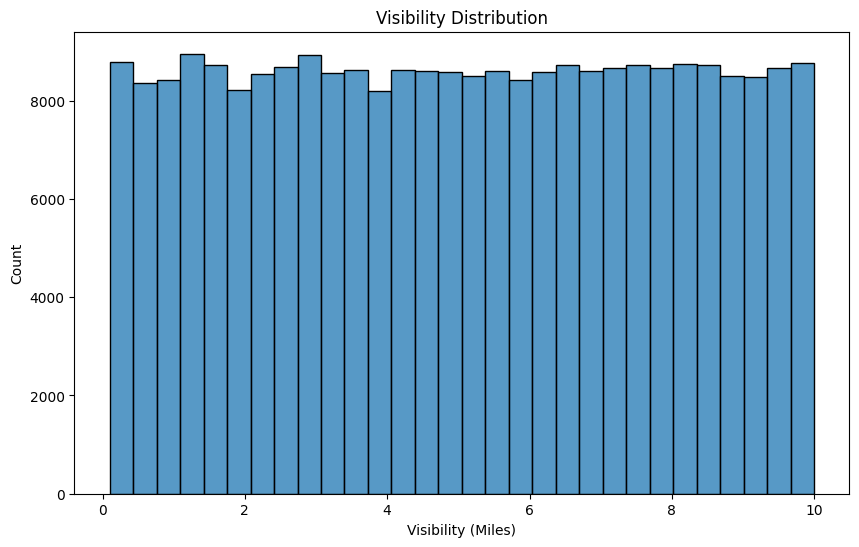

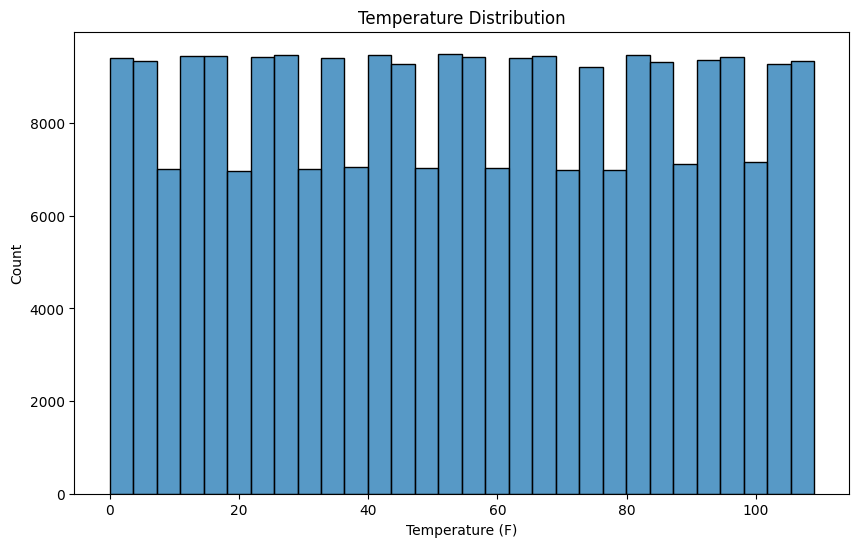

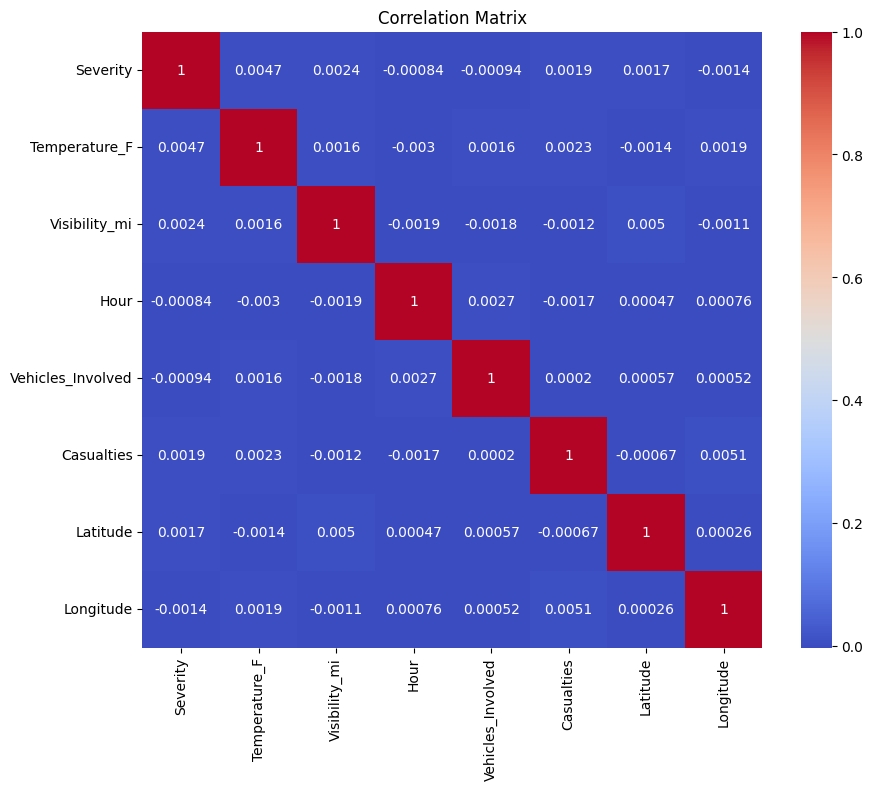

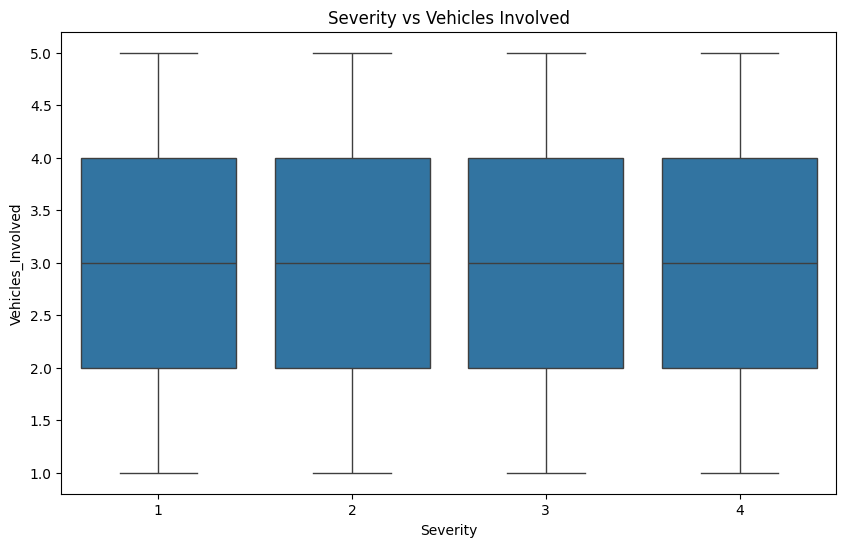

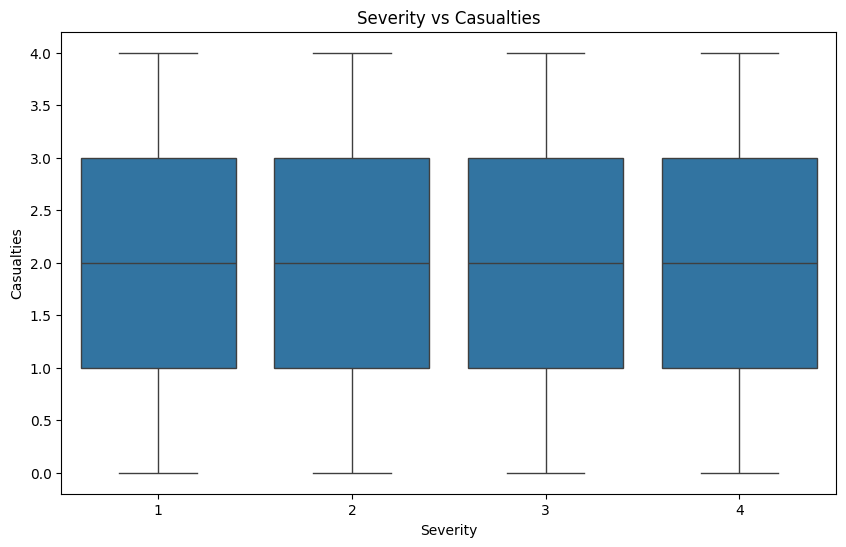

Heatmap Saved Successfully

========== INSIGHTS ==========
Most Common Weather: Cloudy
Most Common Road Condition: Wet
Peak Accident Hour: 3.0
Most Accident-Prone State: CA
Average Visibility: 5.05
Average Temperature: 54.47


In [1]:
# =====================================================
# TRAFFIC ACCIDENT ANALYSIS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("traffic_accidents_synthetic_400mb.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# =====================================================
# BASIC INFO
# =====================================================

print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

# =====================================================
# SEVERITY DISTRIBUTION
# =====================================================

plt.figure(figsize=(8,5))
sns.countplot(x='Severity', data=df)
plt.title("Accident Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Accidents")
plt.show()

# =====================================================
# ACCIDENTS BY HOUR
# =====================================================

hourly = df.groupby('Hour').size()

plt.figure(figsize=(12,6))
hourly.plot(kind='line', marker='o')
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Accident Count")
plt.grid(True)
plt.show()

# =====================================================
# WEATHER CONDITION ANALYSIS
# =====================================================

plt.figure(figsize=(10,6))
df['Weather_Condition'].value_counts().plot(kind='bar')
plt.title("Accidents by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Count")
plt.show()

# =====================================================
# ROAD CONDITION ANALYSIS
# =====================================================

plt.figure(figsize=(8,5))
sns.countplot(x='Road_Condition', data=df)
plt.title("Road Condition Distribution")
plt.show()

# =====================================================
# DAY VS NIGHT ANALYSIS
# =====================================================

plt.figure(figsize=(8,5))
sns.countplot(x='Sunrise_Sunset', data=df)
plt.title("Day vs Night Accidents")
plt.show()

# =====================================================
# TOP STATES
# =====================================================

plt.figure(figsize=(10,6))
df['State'].value_counts().plot(kind='bar')
plt.title("Accidents by State")
plt.xlabel("State")
plt.ylabel("Count")
plt.show()

# =====================================================
# TOP CITIES
# =====================================================

plt.figure(figsize=(10,6))
df['City'].value_counts().plot(kind='bar')
plt.title("Accidents by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

# =====================================================
# WEATHER VS SEVERITY
# =====================================================

weather_severity = pd.crosstab(
    df['Weather_Condition'],
    df['Severity']
)

weather_severity.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Weather Condition vs Severity")
plt.xlabel("Weather Condition")
plt.ylabel("Accident Count")
plt.show()

# =====================================================
# ROAD CONDITION VS SEVERITY
# =====================================================

road_severity = pd.crosstab(
    df['Road_Condition'],
    df['Severity']
)

road_severity.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Road Condition vs Severity")
plt.show()

# =====================================================
# VISIBILITY ANALYSIS
# =====================================================

plt.figure(figsize=(10,6))
sns.histplot(df['Visibility_mi'], bins=30)
plt.title("Visibility Distribution")
plt.xlabel("Visibility (Miles)")
plt.show()

# =====================================================
# TEMPERATURE ANALYSIS
# =====================================================

plt.figure(figsize=(10,6))
sns.histplot(df['Temperature_F'], bins=30)
plt.title("Temperature Distribution")
plt.xlabel("Temperature (F)")
plt.show()

# =====================================================
# CORRELATION HEATMAP
# =====================================================

numeric_cols = [
    'Severity',
    'Temperature_F',
    'Visibility_mi',
    'Hour',
    'Vehicles_Involved',
    'Casualties',
    'Latitude',
    'Longitude'
]

plt.figure(figsize=(10,8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

# =====================================================
# SEVERITY VS VEHICLES INVOLVED
# =====================================================

plt.figure(figsize=(10,6))
sns.boxplot(
    x='Severity',
    y='Vehicles_Involved',
    data=df
)

plt.title("Severity vs Vehicles Involved")
plt.show()

# =====================================================
# CASUALTIES ANALYSIS
# =====================================================

plt.figure(figsize=(10,6))
sns.boxplot(
    x='Severity',
    y='Casualties',
    data=df
)

plt.title("Severity vs Casualties")
plt.show()

# =====================================================
# HOTSPOT MAP
# =====================================================

import folium
from folium.plugins import HeatMap

sample = df.sample(
    min(10000, len(df)),
    random_state=42
)

m = folium.Map(
    location=[
        sample['Latitude'].mean(),
        sample['Longitude'].mean()
    ],
    zoom_start=4
)

heat_data = list(
    zip(
        sample['Latitude'],
        sample['Longitude']
    )
)

HeatMap(heat_data).add_to(m)

m.save("Traffic_Accident_Hotspots.html")

print("Heatmap Saved Successfully")

# =====================================================
# FINAL INSIGHTS
# =====================================================

print("\n========== INSIGHTS ==========")

print(
    "Most Common Weather:",
    df['Weather_Condition'].mode()[0]
)

print(
    "Most Common Road Condition:",
    df['Road_Condition'].mode()[0]
)

print(
    "Peak Accident Hour:",
    df['Hour'].mode()[0]
)

print(
    "Most Accident-Prone State:",
    df['State'].mode()[0]
)

print(
    "Average Visibility:",
    round(df['Visibility_mi'].mean(),2)
)

print(
    "Average Temperature:",
    round(df['Temperature_F'].mean(),2)
)

print("==============================")